# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [65]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [66]:

# Load the dataset
df = pd.read_csv("colorectal_cancer_prediction.csv")

# Display basic information about the dataset
df.head()
print(df.shape)
print(df.info())



(89945, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI       

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

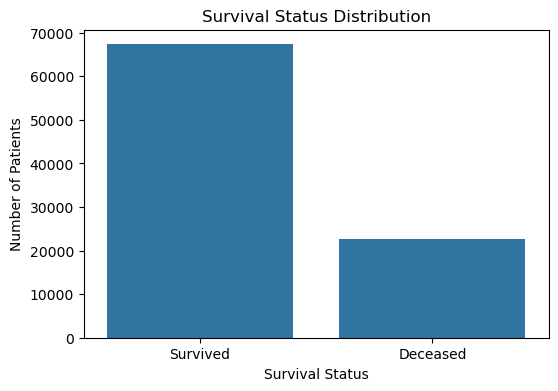

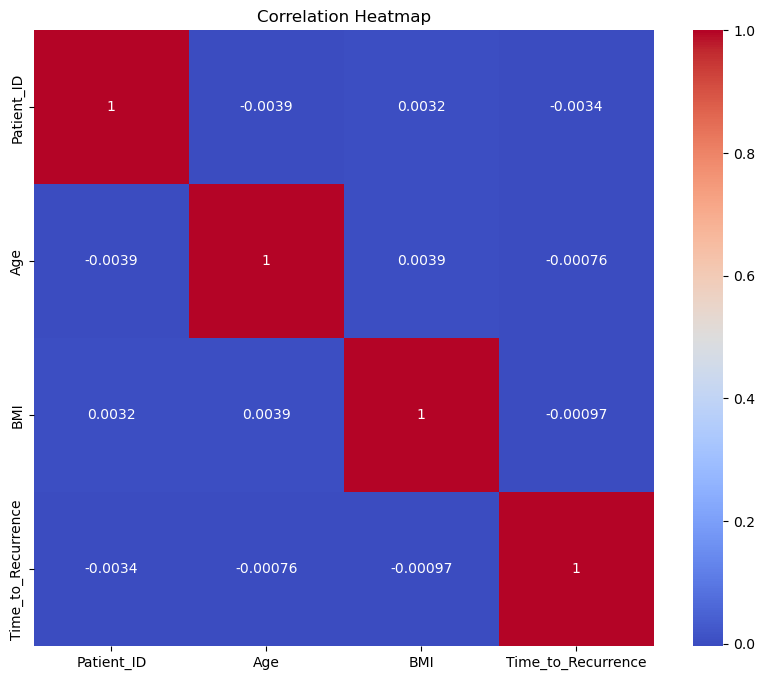

In [67]:

# Check for missing values
df.isnull()

# Visualize survival status distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Survival_Status', data=df)
plt.title('Survival Status Distribution')
plt.xlabel('Survival Status')
plt.ylabel('Number of Patients')
plt.show()

# Correlation heatmap (numerical features only)

plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [68]:

# Drop unnecessary columns (e.g., Patient ID if present)
df.drop_duplicates(inplace=True)

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display updated dataset
print(df.head())

# Define features and target variable
X = df.drop(['Patient_ID', 'Survival_Status'], axis=1)
y = df['Survival_Status']


# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

   Patient_ID  Age  Gender  Race  Region  Urban_or_Rural  \
0           1   71       1     3       2               1   
1           2   34       0     1       4               1   
2           3   80       0     4       4               1   
3           4   40       1     1       4               0   
4           5   43       0     4       2               1   

   Socioeconomic_Status  Family_History  Previous_Cancer_History  \
0                     2               1                        0   
1                     2               0                        0   
2                     2               0                        0   
3                     1               0                        0   
4                     0               1                        0   

   Stage_at_Diagnosis  ...  Insurance_Coverage  Time_to_Diagnosis  \
0                   2  ...                   1                  0   
1                   0  ...                   0                  1   
2                   2  

In [69]:
#feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [70]:
# Train a Logistic Regression model
model = LogisticRegression(
    class_weight='balanced',   # Handles imbalance between survival classes
    max_iter=1000,             # Increases iteration limit for better convergence
    random_state=42            # Keeps results consistent every run
)

In [71]:
# Train the model using training data
model.fit(X_train, y_train)

# Predict survival status using test data
y_pred = model.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Display classification metrics
print(classification_report(y_test, y_pred))

Model Accuracy: 0.501528711990661
              precision    recall  f1-score   support

           0       0.25      0.48      0.33      4471
           1       0.75      0.51      0.60     13518

    accuracy                           0.50     17989
   macro avg       0.50      0.50      0.47     17989
weighted avg       0.62      0.50      0.54     17989



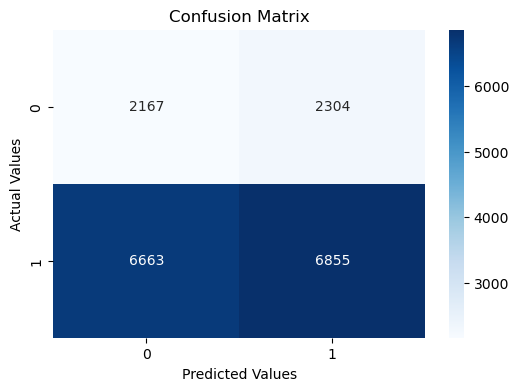

In [72]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.show()

In [73]:
#classification_report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.48      0.33      4471
           1       0.75      0.51      0.60     13518

    accuracy                           0.50     17989
   macro avg       0.50      0.50      0.47     17989
weighted avg       0.62      0.50      0.54     17989



#CONCLUSION


cThis project used Logistic Regression to predict colorectal cancer survival status.
The dataset was preprocessed using encoding and feature scaling techniques.
The model was trained and evaluated using accuracy score, classification report,
and confusion matrix. The project demonstrates the application of machine learning
in healthcare prediction systems.